<a href="https://colab.research.google.com/github/Ashmita001/Mini_Project/blob/main/hello.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup: Library Imports
This cell imports all necessary Python libraries for data manipulation, machine learning, and visualization.

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, f1_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Data Loading
This cell loads the dataset from the specified CSV file into a pandas DataFrame.

In [4]:
df = pd.read_csv('/content/code_dataset.csv')


## Initial Data Inspection
This cell performs an initial check of the loaded dataset, displaying its dimensions, column names, class distribution for 'defects', and any missing values.

In [5]:
print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nClass distribution:\n{df['defects'].value_counts().to_string()}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum()>0].to_string() or 'None'}")

✅ Dataset loaded: 10885 rows × 22 columns

Columns: ['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount', 'defects']

Class distribution:
defects
False    8779
True     2106

Missing values:
Series([], )


## Data Preprocessing & Feature Engineering
This cell defines feature names, converts specific columns to numeric types, handles potential NaN values by dropping rows, converts the target variable 'defects' to integer, and engineers new ratio-based features.

In [6]:
FEATURE_NAMES = [
    'loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd',
    'i', 'e', 'b', 't', 'lOCode', 'lOComment', 'lOBlank',
    'locCodeAndComment', 'uniq_Op', 'uniq_Opnd',
    'total_Op', 'total_Opnd', 'branchCount'
]

cols_to_convert = ['uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['defects'] = df['defects'].astype(int)
df = df.dropna()

# Feature engineering — ratio features
df['op_ratio']         = df['uniq_Op']   / (df['total_Op']   + 1)
df['opnd_ratio']       = df['uniq_Opnd'] / (df['total_Opnd'] + 1)
df['complexity_ratio'] = df['ev(g)']     / (df['v(g)']       + 1)
df['volume_per_line']  = df['v']         / (df['loc']         + 1)
df['comment_ratio']    = df['lOComment'] / (df['loc']         + 1)

ALL_FEATURES = FEATURE_NAMES + [
    'op_ratio', 'opnd_ratio', 'complexity_ratio',
    'volume_per_line', 'comment_ratio'
]

X = df[ALL_FEATURES]
y = df['defects']

print(f"✅ Preprocessing done!")
print(f"   Features: {X.shape[1]}  (21 original + 5 engineered)")
print(f"   Samples : {X.shape[0]}")

✅ Preprocessing done!
   Features: 26  (21 original + 5 engineered)
   Samples : 10880


## Data Splitting, Resampling & Scaling
This cell splits the data into training and testing sets, applies SMOTE to balance the training set, and scales the features using `StandardScaler`.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)

print(f"✅ Split & SMOTE done!")
print(f"   Train (after SMOTE): {X_train_sc.shape[0]} samples")
print(f"   Test               : {X_test_sc.shape[0]} samples")


✅ Split & SMOTE done!
   Train (after SMOTE): 14044 samples
   Test               : 2176 samples


## Model Definition: Stacking Ensemble
This cell defines the base estimators and the meta-learner for the `StackingClassifier` model. The base estimators include RandomForest, ExtraTrees, GradientBoosting, XGBoost, and LightGBM, with LogisticRegression as the final estimator.

In [8]:
print("⏳ Training stacking ensemble (takes ~1–2 min)...\n")

estimators = [
    ('rf',   RandomForestClassifier(
                n_estimators=200, max_depth=12,
                class_weight='balanced', random_state=42, n_jobs=-1)),
    ('et',   ExtraTreesClassifier(
                n_estimators=200, class_weight='balanced',
                random_state=42, n_jobs=-1)),
    ('gb',   GradientBoostingClassifier(
                n_estimators=100, learning_rate=0.05,
                max_depth=5, random_state=42)),
    ('xgb',  XGBClassifier(
                n_estimators=200, learning_rate=0.05, max_depth=6,
                scale_pos_weight=3, eval_metric='auc',
                random_state=42, n_jobs=-1)),
    ('lgbm', LGBMClassifier(
                n_estimators=200, learning_rate=0.05,
                class_weight='balanced', random_state=42,
                n_jobs=-1, verbose=-1)),
]

meta = LogisticRegression(
    C=1.0, class_weight='balanced',
    max_iter=1000, random_state=42
)

MODEL = StackingClassifier(
    estimators=estimators,
    final_estimator=meta,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

⏳ Training stacking ensemble (takes ~1–2 min)...



## Model Training
This cell trains the defined `StackingClassifier` model using the scaled and resampled training data.

In [9]:
MODEL.fit(X_train_sc, y_train_res)
print("✅ Model trained!")

✅ Model trained!


## Model Evaluation on Test Set
This cell evaluates the trained model on the unseen test set, calculates various metrics like accuracy, ROC-AUC, F1-score, and determines risk thresholds based on probability percentiles.

In [10]:
THRESHOLD   = 0.38
test_probs  = MODEL.predict_proba(X_test_sc)[:, 1]
test_preds  = (test_probs > THRESHOLD).astype(int)

LOW_THRESH  = np.percentile(test_probs, 33)
HIGH_THRESH = np.percentile(test_probs, 66)

print("=" * 55)
print("  MODEL EVALUATION ON TEST SET")
print("=" * 55)
print(f"  Accuracy : {accuracy_score(y_test, test_preds):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, test_probs):.4f}")
print(f"  F1-Score : {f1_score(y_test, test_preds):.4f}")
print(f"\n{classification_report(y_test, test_preds, target_names=['No Defect','Defect'])}")
print(f"\nRisk thresholds (percentile-based):")
print(f"  Low Risk    : prob < {LOW_THRESH:.4f}")
print(f"  Medium Risk : {LOW_THRESH:.4f} – {HIGH_THRESH:.4f}")
print(f"  High Risk   : prob > {HIGH_THRESH:.4f}")



  MODEL EVALUATION ON TEST SET
  Accuracy : 0.7794
  ROC-AUC  : 0.7444
  F1-Score : 0.4132

              precision    recall  f1-score   support

   No Defect       0.86      0.87      0.86      1755
      Defect       0.43      0.40      0.41       421

    accuracy                           0.78      2176
   macro avg       0.64      0.64      0.64      2176
weighted avg       0.77      0.78      0.78      2176


Risk thresholds (percentile-based):
  Low Risk    : prob < 0.0366
  Medium Risk : 0.0366 – 0.1543
  High Risk   : prob > 0.1543


## Visualization: Confusion Matrix & Probability Distribution
This cell generates and displays a confusion matrix and a histogram of predicted probabilities to visually assess the model's performance and decision boundary.

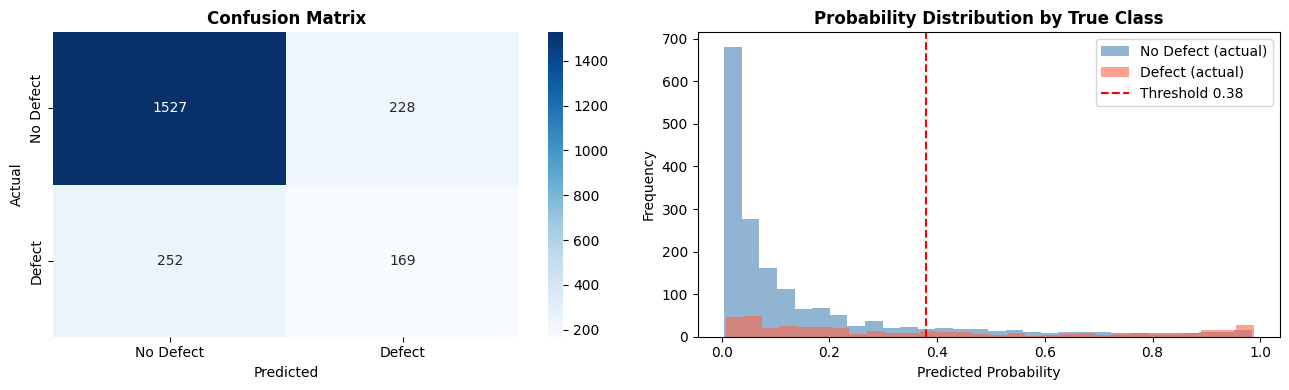

📊 Plot saved to /content/model_evaluation.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Defect','Defect'],
            yticklabels=['No Defect','Defect'])
axes[0].set_title("Confusion Matrix", fontweight='bold')
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

axes[1].hist(test_probs[y_test==0], bins=30, alpha=0.6, color='steelblue', label='No Defect (actual)')
axes[1].hist(test_probs[y_test==1], bins=30, alpha=0.6, color='tomato',    label='Defect (actual)')
axes[1].axvline(THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Threshold {THRESHOLD}')
axes[1].set_title("Probability Distribution by True Class", fontweight='bold')
axes[1].set_xlabel("Predicted Probability"); axes[1].set_ylabel("Frequency")
axes[1].legend()
plt.tight_layout()
plt.savefig('/content/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot saved to /content/model_evaluation.png")

## Single Prediction Helper Function
This cell defines a function `predict_single` that takes a comma-separated string of feature values, preprocesses it, and provides a defect prediction along with probability and risk level.

In [12]:
def get_risk_level(prob):
    if prob > HIGH_THRESH:
        return "🔴 High Risk"
    elif prob > LOW_THRESH:
        return "🟡 Medium Risk"
    else:
        return "🟢 Low Risk"


def predict_single(csv_string):
    """
    Predict from one comma-separated string of 21 values.

    Feature order:
      loc, v(g), ev(g), iv(g), n, v, l, d, i, e, b, t,
      lOCode, lOComment, lOBlank, locCodeAndComment,
      uniq_Op, uniq_Opnd, total_Op, total_Opnd, branchCount
    """
    parts = [v.strip() for v in csv_string.strip().split(',')]

    if len(parts) != 21:
        print(f"❌ ERROR: Expected 21 values, got {len(parts)}")
        print("   Required order: " + ", ".join(FEATURE_NAMES))
        return None

    try:
        vals = [float(p) for p in parts]
    except ValueError as err:
        print(f"❌ ERROR: Non-numeric value — {err}")
        return None

    # Build row with same 21 original features
    row_orig = pd.DataFrame([vals], columns=FEATURE_NAMES)

    # Add engineered features
    row_orig['op_ratio']         = row_orig['uniq_Op']   / (row_orig['total_Op']   + 1)
    row_orig['opnd_ratio']       = row_orig['uniq_Opnd'] / (row_orig['total_Opnd'] + 1)
    row_orig['complexity_ratio'] = row_orig['ev(g)']     / (row_orig['v(g)']       + 1)
    row_orig['volume_per_line']  = row_orig['v']         / (row_orig['loc']         + 1)
    row_orig['comment_ratio']    = row_orig['lOComment'] / (row_orig['loc']         + 1)

    row_sc = scaler.transform(row_orig[ALL_FEATURES])
    prob   = MODEL.predict_proba(row_sc)[0][1]
    pred   = int(prob > THRESHOLD)
    risk   = get_risk_level(prob)
    label  = "DEFECT ⚠️" if pred == 1 else "NO DEFECT ✅"

    print("\n" + "━" * 50)
    print("  PREDICTION RESULT")
    print("━" * 50)
    print(f"  Result      :  {label}")
    print(f"  Binary      :  {pred}   (1 = Defect, 0 = No Defect)")
    print(f"  Probability :  {prob:.4f}  ({prob*100:.1f}%)")
    print(f"  Risk Level  :  {risk}")
    print(f"  Threshold   :  {THRESHOLD} (decision boundary)")
    print("━" * 50)

    return {
        'label': 'DEFECT' if pred == 1 else 'NO DEFECT',
        'prediction': pred,
        'probability': round(prob, 4),
        'risk': risk
    }


## Helper Functions Summary
This cell confirms that helper functions are ready and lists the available functions for prediction.

predicting batch

In [13]:
# def predict_batch(csv_lines):
#     """
#     Predict for multiple samples.
#     Pass a list of CSV strings, or a single multi-line string.

#     Example:
#         predict_batch([
#             "20,3,2,2,90,300,0.07,40,7,12000,1.2,820,18,2,1,0,18,12,50,40,6",
#             "5,1,1,1,30,80,0.10,10,8,800,0.3,55,5,0,0,0,8,6,14,12,2",
#         ])
#     """
#     if isinstance(csv_lines, str):
#         csv_lines = [l for l in csv_lines.strip().split('\n') if l.strip()]

#     records = []
#     for i, line in enumerate(csv_lines, 1):
#         parts = [v.strip() for v in line.strip().split(',')]
#         if len(parts) != 21:
#             print(f"⚠️  Row {i}: skipped — expected 21 values, got {len(parts)}")
#             continue
#         try:
#             vals = [float(p) for p in parts]
#         except ValueError:
#             print(f"⚠️  Row {i}: skipped — non-numeric value")
#             continue

#         row = pd.DataFrame([vals], columns=FEATURE_NAMES)
#         row['op_ratio']         = row['uniq_Op']   / (row['total_Op']   + 1)
#         row['opnd_ratio']       = row['uniq_Opnd'] / (row['total_Opnd'] + 1)
#         row['complexity_ratio'] = row['ev(g)']     / (row['v(g)']       + 1)
#         row['volume_per_line']  = row['v']         / (row['loc']         + 1)
#         row['comment_ratio']    = row['lOComment'] / (row['loc']         + 1)

#         row_sc = scaler.transform(row[ALL_FEATURES])
#         prob   = MODEL.predict_proba(row_sc)[0][1]
#         pred   = int(prob > THRESHOLD)
#         risk_raw = ('High' if prob > HIGH_THRESH
#                     else 'Medium' if prob > LOW_THRESH
#                     else 'Low')

#         records.append({
#             'Row':         i,
#             'Prediction':  pred,
#             'Label':       'DEFECT' if pred == 1 else 'NO DEFECT',
#             'Probability': round(prob, 4),
#             'Risk':        risk_raw,
#         })

#     if not records:
#         print("❌ No valid rows to predict.")
#         return None

#     result_df = pd.DataFrame(records)

#     print("\n" + "━" * 65)
#     print("  BATCH PREDICTION RESULTS")
#     print("━" * 65)
#     print(result_df.to_string(index=False))
#     print("━" * 65)
#     defect_count = result_df['Prediction'].sum()
#     clean_count  = len(result_df) - defect_count
#     print(f"  Total: {len(result_df)} rows  |  "
#           f"Defects: {defect_count}  |  Clean: {clean_count}")
#     print("━" * 65)

interactive prediction

In [14]:
# def interactive_predict():
#     """
#     Loop: keep asking for CSV input until user types 'quit'.
#     Type 'batch' to enter multiple rows at once.
#     Type 'example' to see a sample input.
#     """
#     EXAMPLE = ("20,3,2,2,90,300,0.07,40,7,12000,1.2,820,"
#                "18,2,1,0,18,12,50,40,6")

#     print("\n" + "━" * 55)
#     print("  INTERACTIVE DEFECT PREDICTOR")
#     print("━" * 55)
#     print("Enter 21 comma-separated values in this order:")
#     print(", ".join(FEATURE_NAMES))
#     print("\nCommands:  'example'  'batch'  'quit'")
#     print("━" * 55)

#     while True:
#         user_input = input("\nEnter values (or command): ").strip()

#         if not user_input:
#             continue

#         if user_input.lower() == 'quit':
#             print("👋 Exiting predictor.")
#             break

#         elif user_input.lower() == 'example':
#             print(f"\n📋 Example input (21 values):\n   {EXAMPLE}")
#             print("   Copy and paste it above to test.")

#         elif user_input.lower() == 'batch':
#             print("Paste rows (one per line). Enter a blank line when done:")
#             lines = []
#             while True:
#                 line = input()
#                 if line.strip() == '':
#                     break
#                 lines.append(line)
#             if lines:
#                 predict_batch(lines)
#             else:
#                 print("No rows entered.")

#         else:
#             predict_single(user_input)


print("✅ Helper functions ready!")
print("\nFunctions available:")
print("  predict_single('v1,v2,...,v21')  — predict one row")
# print("  predict_batch([...])             — predict multiple rows")
# print("  interactive_predict()            — interactive loop")

✅ Helper functions ready!

Functions available:
  predict_single('v1,v2,...,v21')  — predict one row


## Sample Single Prediction
This cell demonstrates the usage of the `predict_single` function with a sample input string.

In [48]:
sample_input = "160,5,4,3,698,4862.12,0.03,33.11,146.86,160969.13,1.62,8942.73,123,11,23,1,22,103,388,310,9"

result = predict_single(sample_input)



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PREDICTION RESULT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Result      :  DEFECT ⚠️
  Binary      :  1   (1 = Defect, 0 = No Defect)
  Probability :  0.9718  (97.2%)
  Risk Level  :  🔴 High Risk
  Threshold   :  0.38 (decision boundary)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## Comprehensive Training & Testing Metrics
This cell calculates and displays a detailed set of evaluation metrics for both the training and testing sets, including accuracy, precision, recall, F1-score, ROC-AUC, and an overfitting check.

# Training and Testing

In [49]:
# ──────────────────────────────────────────────
# CELL 7B — Full Training & Testing Metrics
# ──────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    matthews_corrcoef, cohen_kappa_score, log_loss,
    precision_recall_curve, roc_curve, average_precision_score
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# ── Get predictions on both sets
train_probs = MODEL.predict_proba(X_train_sc)[:, 1]
train_preds = (train_probs > THRESHOLD).astype(int)

test_probs  = MODEL.predict_proba(X_test_sc)[:, 1]
test_preds  = (test_probs  > THRESHOLD).astype(int)

# ── Compute all metrics
def get_metrics(y_true, y_pred, y_prob, label):
    cm  = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Split':             label,
        'Accuracy':          round(accuracy_score(y_true, y_pred),        4),
        'Precision':         round(precision_score(y_true, y_pred),       4),
        'Recall (Sensitivity)': round(recall_score(y_true, y_pred),       4),
        'Specificity':       round(tn / (tn + fp),                        4),
        'F1-Score':          round(f1_score(y_true, y_pred),              4),
        'ROC-AUC':           round(roc_auc_score(y_true, y_prob),         4),
        'Avg Precision':     round(average_precision_score(y_true, y_prob),4),
        'MCC':               round(matthews_corrcoef(y_true, y_pred),     4),
        "Cohen's Kappa":     round(cohen_kappa_score(y_true, y_pred),     4),
        'Log Loss':          round(log_loss(y_true, y_prob),              4),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
    }

train_metrics = get_metrics(y_train_res, train_preds, train_probs, 'TRAIN')
test_metrics  = get_metrics(y_test,      test_preds,  test_probs,  'TEST')

# ── Print side-by-side table
metrics_df = pd.DataFrame([train_metrics, test_metrics]).set_index('Split')
print("\n" + "=" * 65)
print("  TRAINING vs TESTING METRICS")
print("=" * 65)
print(metrics_df.T.to_string())
print("=" * 65)

# Overfit check
acc_diff = train_metrics['Accuracy'] - test_metrics['Accuracy']
auc_diff = train_metrics['ROC-AUC']  - test_metrics['ROC-AUC']
print(f"\n  Accuracy gap (train - test) : {acc_diff:+.4f}", end="  ")
print("⚠️  Possible overfit" if acc_diff > 0.10 else "✅ OK")
print(f"  AUC gap      (train - test) : {auc_diff:+.4f}", end="  ")
print("⚠️  Possible overfit" if auc_diff > 0.10 else "✅ OK")

# ── Classification reports
print("\n── TRAIN Classification Report ──")
print(classification_report(y_train_res, train_preds,
                             target_names=['No Defect', 'Defect']))
print("── TEST Classification Report ──")
print(classification_report(y_test, test_preds,
                             target_names=['No Defect', 'Defect']))






  TRAINING vs TESTING METRICS
Split                     TRAIN       TEST
Accuracy                 0.9902     0.7794
Precision                0.9964     0.4257
Recall (Sensitivity)     0.9841     0.4014
Specificity              0.9964     0.8701
F1-Score                 0.9902     0.4132
ROC-AUC                  0.9996     0.7444
Avg Precision            0.9996     0.4301
MCC                      0.9806     0.2777
Cohen's Kappa            0.9805     0.2775
Log Loss                 0.0397     0.4917
TP                    6910.0000   169.0000
TN                    6997.0000  1527.0000
FP                      25.0000   228.0000
FN                     112.0000   252.0000

  Accuracy gap (train - test) : +0.2108  ⚠️  Possible overfit
  AUC gap      (train - test) : +0.2552  ⚠️  Possible overfit

── TRAIN Classification Report ──
              precision    recall  f1-score   support

   No Defect       0.98      1.00      0.99      7022
      Defect       1.00      0.98      0.99      7022



## Detailed Model Evaluation Plots
This cell generates a comprehensive multi-plot figure to visually assess the model's performance and potential overfitting. The plots include:
*   **Metric Comparisons:** Train vs. Test metrics for key performance indicators.
*   **Overfit Gap Analysis:** Visualizing the difference between train and test scores to identify overfitting.
*   **Confusion Matrices:** For both training and testing sets.
*   **Prediction Breakdown:** A pie chart showing the distribution of true positives, true negatives, false positives, and false negatives on the test set.
*   **ROC Curves:** Receiver Operating Characteristic curves for both train and test sets.
*   **Precision-Recall Curves:** For both train and test sets.
*   **Test Probability Distribution:** A histogram of predicted probabilities by true class, highlighting the decision threshold.

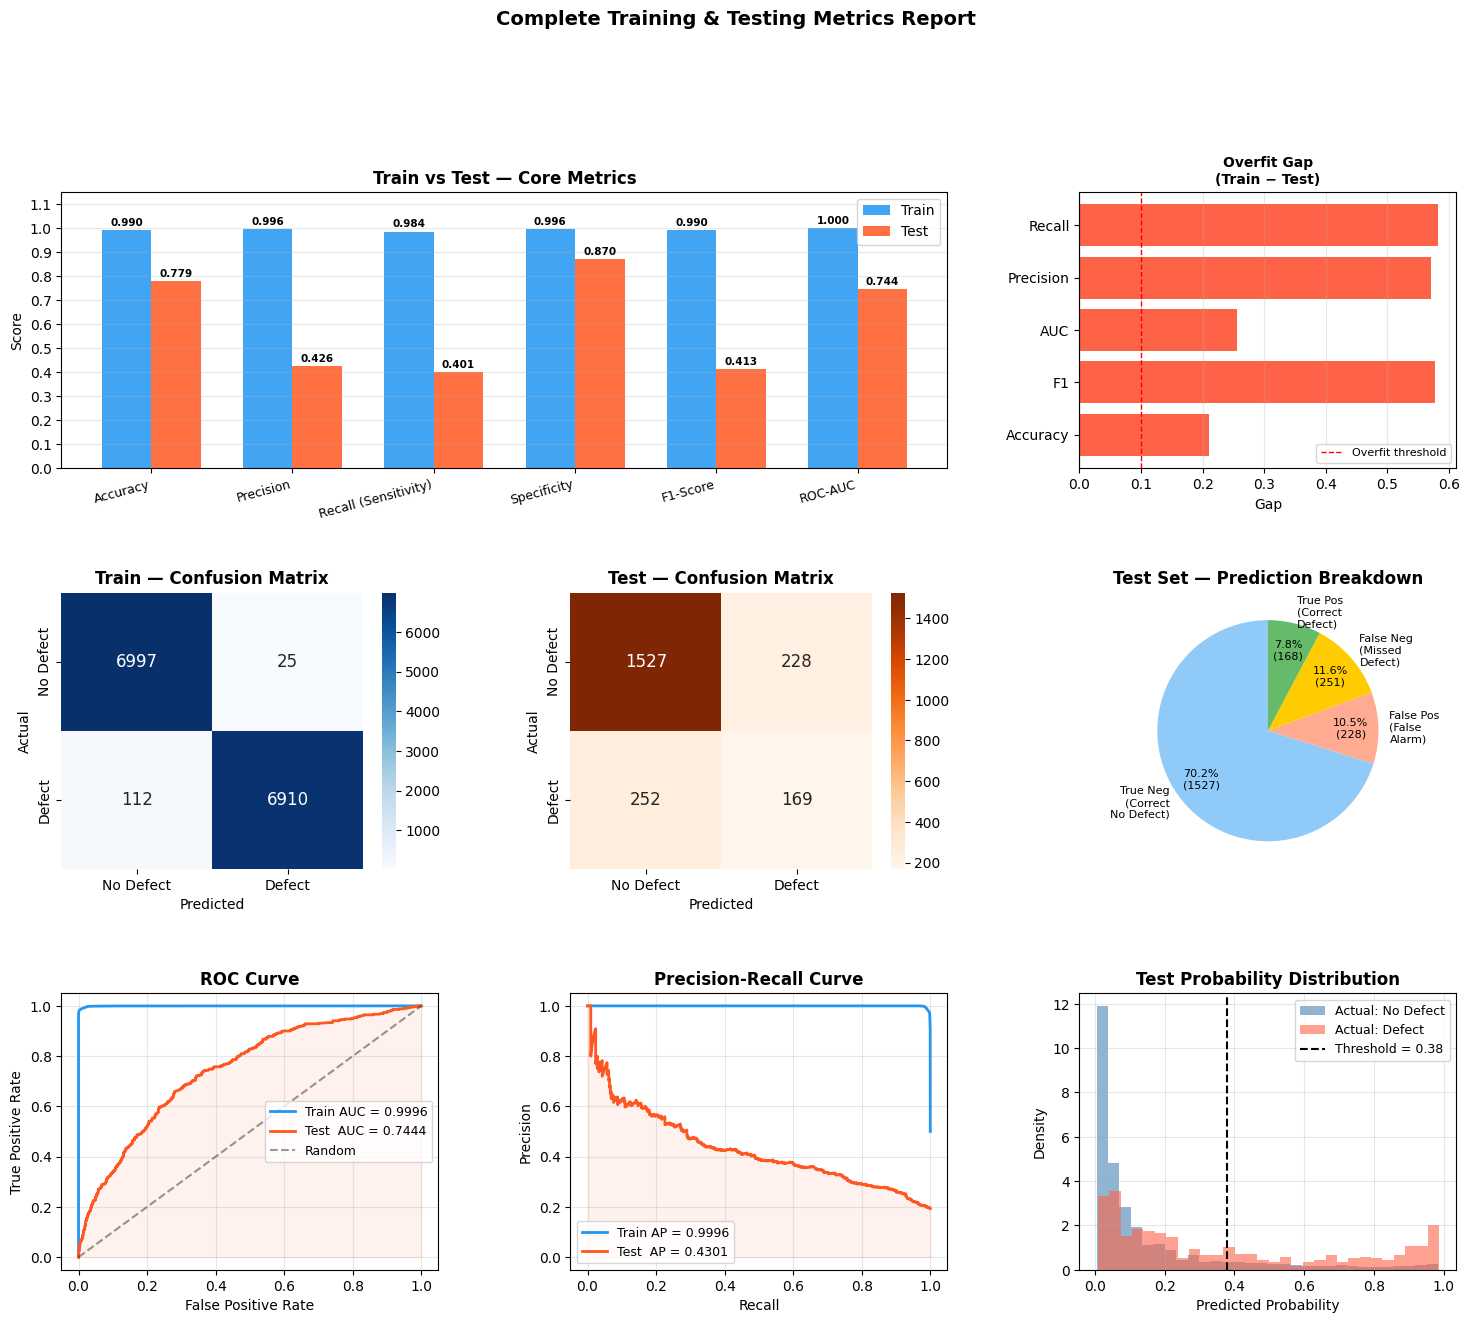

📊 Full report saved to /content/full_metrics_report.png


In [50]:
# ──────────────────────────────────────────────
# PLOTS
# ──────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

TRAIN_COL = '#2196F3'
TEST_COL  = '#FF5722'

# ── 1. Metrics bar comparison
ax1 = fig.add_subplot(gs[0, :2])
compare_metrics = ['Accuracy', 'Precision', 'Recall (Sensitivity)',
                   'Specificity', 'F1-Score', 'ROC-AUC']
x    = np.arange(len(compare_metrics))
w    = 0.35
bars_tr = ax1.bar(x - w/2,
                  [train_metrics[m] for m in compare_metrics],
                  w, label='Train', color=TRAIN_COL, alpha=0.85)
bars_te = ax1.bar(x + w/2,
                  [test_metrics[m]  for m in compare_metrics],
                  w, label='Test',  color=TEST_COL,  alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(compare_metrics, rotation=15, ha='right', fontsize=9)
ax1.set_ylim(0, 1.15)
ax1.set_ylabel("Score")
ax1.set_title("Train vs Test — Core Metrics", fontweight='bold')
ax1.legend()
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.grid(axis='y', alpha=0.3)
for bar in list(bars_tr) + list(bars_te):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.3f}',
             ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# ── 2. Overfit gap
ax2 = fig.add_subplot(gs[0, 2])
gap_labels  = ['Accuracy', 'F1', 'AUC', 'Precision', 'Recall']
gap_values  = [
    train_metrics['Accuracy']              - test_metrics['Accuracy'],
    train_metrics['F1-Score']              - test_metrics['F1-Score'],
    train_metrics['ROC-AUC']               - test_metrics['ROC-AUC'],
    train_metrics['Precision']             - test_metrics['Precision'],
    train_metrics['Recall (Sensitivity)']  - test_metrics['Recall (Sensitivity)'],
]
colors_gap = ['tomato' if g > 0.10 else 'steelblue' for g in gap_values]
ax2.barh(gap_labels, gap_values, color=colors_gap)
ax2.axvline(0,    color='black', linewidth=0.8)
ax2.axvline(0.10, color='red',   linewidth=1, linestyle='--', label='Overfit threshold')
ax2.set_title("Overfit Gap\n(Train − Test)", fontweight='bold', fontsize=10)
ax2.set_xlabel("Gap")
ax2.legend(fontsize=8)
ax2.grid(axis='x', alpha=0.3)

# ── 3. Train confusion matrix
ax3 = fig.add_subplot(gs[1, 0])
cm_train = confusion_matrix(y_train_res, train_preds)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['No Defect','Defect'],
            yticklabels=['No Defect','Defect'],
            annot_kws={"size": 12})
ax3.set_title("Train — Confusion Matrix", fontweight='bold')
ax3.set_xlabel("Predicted"); ax3.set_ylabel("Actual")

# ── 4. Test confusion matrix
ax4 = fig.add_subplot(gs[1, 1])
cm_test = confusion_matrix(y_test, test_preds)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=ax4,
            xticklabels=['No Defect','Defect'],
            yticklabels=['No Defect','Defect'],
            annot_kws={"size": 12})
ax4.set_title("Test — Confusion Matrix", fontweight='bold')
ax4.set_xlabel("Predicted"); ax4.set_ylabel("Actual")

# ── 5. Confusion matrix % breakdown (test)
ax5 = fig.add_subplot(gs[1, 2])
tn, fp, fn, tp = cm_test.ravel()
total   = tn + fp + fn + tp
labels  = ['True Neg\n(Correct\nNo Defect)', 'False Pos\n(False\nAlarm)',
           'False Neg\n(Missed\nDefect)',     'True Pos\n(Correct\nDefect)']
values  = [tn, fp, fn, tp]
colors  = ['#90CAF9', '#FFAB91', '#FFCC02', '#66BB6A']
wedges, texts, autotexts = ax5.pie(
    values, labels=labels, autopct=lambda p: f'{p:.1f}%\n({int(p*total/100)})',
    colors=colors, startangle=90,
    textprops={'fontsize': 8}, pctdistance=0.75
)
ax5.set_title("Test Set — Prediction Breakdown", fontweight='bold')

# ── 6. ROC curves
ax6 = fig.add_subplot(gs[2, 0])
fpr_tr, tpr_tr, _ = roc_curve(y_train_res, train_probs)
fpr_te, tpr_te, _ = roc_curve(y_test,      test_probs)
ax6.plot(fpr_tr, tpr_tr, color=TRAIN_COL, lw=2,
         label=f'Train AUC = {train_metrics["ROC-AUC"]:.4f}')
ax6.plot(fpr_te, tpr_te, color=TEST_COL,  lw=2,
         label=f'Test  AUC = {test_metrics["ROC-AUC"]:.4f}')
ax6.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
ax6.fill_between(fpr_te, tpr_te, alpha=0.08, color=TEST_COL)
ax6.set_xlabel("False Positive Rate")
ax6.set_ylabel("True Positive Rate")
ax6.set_title("ROC Curve", fontweight='bold')
ax6.legend(fontsize=9); ax6.grid(alpha=0.3)

# ── 7. Precision-Recall curves
ax7 = fig.add_subplot(gs[2, 1])
prec_tr, rec_tr, _ = precision_recall_curve(y_train_res, train_probs)
prec_te, rec_te, _ = precision_recall_curve(y_test,      test_probs)
ax7.plot(rec_tr, prec_tr, color=TRAIN_COL, lw=2,
         label=f'Train AP = {train_metrics["Avg Precision"]:.4f}')
ax7.plot(rec_te, prec_te, color=TEST_COL,  lw=2,
         label=f'Test  AP = {test_metrics["Avg Precision"]:.4f}')
ax7.fill_between(rec_te, prec_te, alpha=0.08, color=TEST_COL)
ax7.set_xlabel("Recall")
ax7.set_ylabel("Precision")
ax7.set_title("Precision-Recall Curve", fontweight='bold')
ax7.legend(fontsize=9); ax7.grid(alpha=0.3)

# ── 8. Probability distributions
ax8 = fig.add_subplot(gs[2, 2])
ax8.hist(test_probs[y_test == 0], bins=30, alpha=0.6,
         color='steelblue', label='Actual: No Defect', density=True)
ax8.hist(test_probs[y_test == 1], bins=30, alpha=0.6,
         color='tomato',    label='Actual: Defect',    density=True)
ax8.axvline(THRESHOLD, color='black', linestyle='--',
            linewidth=1.5, label=f'Threshold = {THRESHOLD}')
ax8.set_xlabel("Predicted Probability")
ax8.set_ylabel("Density")
ax8.set_title("Test Probability Distribution", fontweight='bold')
ax8.legend(fontsize=9); ax8.grid(alpha=0.3)

plt.suptitle("Complete Training & Testing Metrics Report",
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('/content/full_metrics_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Full report saved to /content/full_metrics_report.png")

## Save and Download Model
This cell saves the trained model, scaler, feature names, and thresholds to a pickle file and initiates a download of this file.

downloading pickle file

In [51]:
import joblib
from google.colab import files

# Save all model components together
joblib.dump({
    'model':        MODEL,
    'scaler':       scaler,
    'features':     ALL_FEATURES,
    'threshold':    THRESHOLD,
    'low_thresh':   LOW_THRESH,
    'high_thresh':  HIGH_THRESH,
}, '/content/defect_predictor.pkl')

print("✅ Model saved!")

# Download to your computer
files.download('/content/defect_predictor.pkl')
print("📥 Download started!")

✅ Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Download started!


## GitHub Integration Instructions
This cell provides instructions on how to save the notebook to GitHub directly from Colab or using Git commands.

In [19]:
# To save this notebook to GitHub directly from Colab:
# 1. Go to 'File' in the menu bar.
# 2. Select 'Save a copy to GitHub'.
# 3. You will be prompted to authenticate with your GitHub account (if not already linked).
# 4. Choose the repository where you want to save the notebook.
# 5. You can also specify a commit message and branch.
# 6. Click 'OK' or 'Save'.

# If you want to use Git commands within Colab, here's a general outline:
# !git init
# !git remote add origin <YOUR_GITHUB_REPO_URL>
# !git add .
# !git commit -m "Initial commit of Colab notebook"
# !git branch -M main
# !git push -u origin main

In [20]:
# smote = SMOTE(random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# print(f"\nAfter SMOTE — Train size: {X_train_res.shape[0]}")
# print("SMOTE class balance:\n", pd.Series(y_train_res).value_counts())

In [21]:
# scaler = StandardScaler()
# X_train_sc = scaler.fit_transform(X_train_res)
# X_test_sc  = scaler.transform(X_test)

In [22]:
# print("\n" + "="*55)
# print("  LAYER 1 — BASE MODELS")
# print("="*55)

# base_models = {
#     "Random Forest": RandomForestClassifier(
#         n_estimators=300,
#         max_depth=12,
#         min_samples_split=3,
#         class_weight='balanced',
#         random_state=42,
#         n_jobs=-1
#     ),
#     "Extra Trees": ExtraTreesClassifier(
#         n_estimators=300,
#         max_depth=12,
#         class_weight='balanced',
#         random_state=42,
#         n_jobs=-1
#     ),
#     "Gradient Boosting": GradientBoostingClassifier(
#         n_estimators=200,
#         learning_rate=0.05,
#         max_depth=5,
#         random_state=42
#     ),
#     "XGBoost": XGBClassifier(
#         n_estimators=400,
#         learning_rate=0.03,
#         max_depth=8,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         scale_pos_weight=3,
#         eval_metric='auc',
#         random_state=42,
#         n_jobs=-1
#     ),
#     "LightGBM": LGBMClassifier(
#         n_estimators=400,
#         learning_rate=0.03,
#         max_depth=8,
#         class_weight='balanced',
#         random_state=42,
#         n_jobs=-1,
#         verbose=-1
#     ),
#     "AdaBoost": AdaBoostClassifier(
#         n_estimators=200,
#         learning_rate=0.05,
#         random_state=42
#     ),
#     "Logistic Regression": LogisticRegression(
#         C=1.0,
#         class_weight='balanced',
#         max_iter=1000,
#         random_state=42
#     ),
#     "Naive Bayes": GaussianNB(),
# }

In [23]:
# base_results = {}
# for name, model in base_models.items():
#     model.fit(X_train_sc, y_train_res)
#     preds = model.predict(X_test_sc)
#     probs = model.predict_proba(X_test_sc)[:, 1]
#     acc   = accuracy_score(y_test, preds)
#     auc   = roc_auc_score(y_test, probs)
#     f1    = f1_score(y_test, preds)
#     base_results[name] = {'acc': acc, 'auc': auc, 'f1': f1, 'probs': probs}
#     print(f"  {name:<25} Acc={acc:.4f}  AUC={auc:.4f}  F1={f1:.4f}")


In [24]:
# print("\n" + "="*55)
# print("  WEIGHTED AVERAGE ENSEMBLE")
# print("="*55)

In [25]:
# weights = {
#     "Random Forest":      0.18,
#     "Extra Trees":        0.15,
#     "Gradient Boosting":  0.15,
#     "XGBoost":            0.20,
#     "LightGBM":           0.20,
#     "AdaBoost":           0.05,
#     "Logistic Regression":0.05,
#     "Naive Bayes":        0.02,
# }

# avg_probs = sum(
#     weights[name] * base_results[name]['probs']
#     for name in base_results
# )


In [26]:
# THRESHOLD = 0.38   # tune between 0.35–0.50
# avg_preds = (avg_probs > THRESHOLD).astype(int)

# print(f"\n  Threshold: {THRESHOLD}")
# print(f"  Accuracy : {accuracy_score(y_test, avg_preds):.4f}")
# print(f"  ROC-AUC  : {roc_auc_score(y_test, avg_probs):.4f}")
# print(f"  F1-Score : {f1_score(y_test, avg_preds):.4f}")
# print("\n  Classification Report:\n", classification_report(y_test, avg_preds))

In [27]:
# print("\n" + "="*55)
# print("  STACKING ENSEMBLE  (meta-learner)")
# print("="*55)

In [28]:
# estimators = [
#     ('rf',   RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)),
#     ('et',   ExtraTreesClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)),
#     ('gb',   GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)),
#     ('xgb',  XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, scale_pos_weight=3,
#                             eval_metric='auc', random_state=42, n_jobs=-1)),
#     ('lgbm', LGBMClassifier(n_estimators=200, learning_rate=0.05, class_weight='balanced',
#                              random_state=42, n_jobs=-1, verbose=-1)),
#     ('lr',   LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
# ]

# # Meta-learner: Logistic Regression learns how to combine base model outputs
# meta_learner = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)

# stacking_clf = StackingClassifier(
#     estimators=estimators,
#     final_estimator=meta_learner,
#     cv=5,                   # 5-fold CV for out-of-fold predictions
#     stack_method='predict_proba',
#     passthrough=False,      # set True to also pass raw features to meta-learner
#     n_jobs=-1
# )

# print("  Training stacking classifier (this takes a moment)...")
# stacking_clf.fit(X_train_sc, y_train_res)

# stack_probs = stacking_clf.predict_proba(X_test_sc)[:, 1]
# stack_preds = (stack_probs > THRESHOLD).astype(int)

# print(f"\n  Threshold: {THRESHOLD}")
# print(f"  Accuracy : {accuracy_score(y_test, stack_preds):.4f}")
# print(f"  ROC-AUC  : {roc_auc_score(y_test, stack_probs):.4f}")
# print(f"  F1-Score : {f1_score(y_test, stack_preds):.4f}")
# print("\n  Classification Report:\n", classification_report(y_test, stack_preds))

In [29]:
# print("\n" + "="*55)
# print("  THRESHOLD SWEEP — Stacking model")
# print("="*55)

# thresholds   = np.arange(0.25, 0.65, 0.05)
# sweep_results = []
# for t in thresholds:
#     preds = (stack_probs > t).astype(int)
#     sweep_results.append({
#         'threshold': round(t, 2),
#         'accuracy':  round(accuracy_score(y_test, preds), 4),
#         'f1':        round(f1_score(y_test, preds), 4),
#         'recall':    round(classification_report(y_test, preds, output_dict=True)['1']['recall'], 4),
#         'precision': round(classification_report(y_test, preds, output_dict=True)['1']['precision'], 4),
#     })

# sweep_df = pd.DataFrame(sweep_results)
# print(sweep_df.to_string(index=False))

In [30]:
# low_thresh  = np.percentile(stack_probs, 33)
# high_thresh = np.percentile(stack_probs, 66)

# print(f"\nRisk thresholds (percentile-based):")
# print(f"  Low  < {low_thresh:.4f}")
# print(f"  Med  {low_thresh:.4f} – {high_thresh:.4f}")
# print(f"  High > {high_thresh:.4f}")

# def get_risk(prob):
#     if prob > high_thresh:
#         return "High Risk"
#     elif prob > low_thresh:
#         return "Medium Risk"
#     else:
#         return "Low Risk"

# risk_series = pd.Series([get_risk(p) for p in stack_probs])
# print("\nRisk distribution:\n", risk_series.value_counts())

In [31]:
# fig, axes = plt.subplots(2, 3, figsize=(18, 11))
# fig.suptitle("Software Defect Prediction — Full Model Report", fontsize=15, fontweight='bold')

# # ── 12a. Base model comparison (AUC)
# ax = axes[0, 0]
# names = list(base_results.keys())
# aucs  = [base_results[n]['auc'] for n in names]
# colors = ['#2196F3' if a == max(aucs) else '#90CAF9' for a in aucs]
# bars = ax.barh(names, aucs, color=colors)
# ax.set_xlim(0.5, 1.0)
# ax.set_xlabel("ROC-AUC")
# ax.set_title("Base Model AUC Comparison")
# for bar, val in zip(bars, aucs):
#     ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
#             f'{val:.4f}', va='center', fontsize=9)
# ax.axvline(x=max(aucs), color='#1565C0', linestyle='--', alpha=0.5)

# # ── 12b. Stacking confusion matrix
# ax = axes[0, 1]
# cm = confusion_matrix(y_test, stack_preds)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
#             xticklabels=['No Defect', 'Defect'],
#             yticklabels=['No Defect', 'Defect'])
# ax.set_title("Stacking Model — Confusion Matrix")
# ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

# # ── 12c. ROC curves
# ax = axes[0, 2]
# # Base models (thin)
# for name in ['XGBoost', 'LightGBM', 'Random Forest']:
#     fpr, tpr, _ = roc_curve(y_test, base_results[name]['probs'])
#     ax.plot(fpr, tpr, alpha=0.5, linewidth=1, label=f"{name} ({base_results[name]['auc']:.3f})")
# # Weighted avg
# fpr, tpr, _ = roc_curve(y_test, avg_probs)
# ax.plot(fpr, tpr, color='orange', linewidth=2, label=f"Weighted Avg ({roc_auc_score(y_test, avg_probs):.3f})")
# # Stacking
# fpr, tpr, _ = roc_curve(y_test, stack_probs)
# ax.plot(fpr, tpr, color='red', linewidth=2.5, label=f"Stacking ({roc_auc_score(y_test, stack_probs):.3f})")
# ax.plot([0,1],[0,1],'k--', alpha=0.3)
# ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
# ax.set_title("ROC Curves — All Models")
# ax.legend(fontsize=8)

# # ── 12d. Probability distribution
# ax = axes[1, 0]
# ax.hist(stack_probs[y_test == 0], bins=30, alpha=0.6, color='steelblue', label='No Defect')
# ax.hist(stack_probs[y_test == 1], bins=30, alpha=0.6, color='coral', label='Defect')
# ax.axvline(x=THRESHOLD, color='red', linestyle='--', label=f'Threshold {THRESHOLD}')
# ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Frequency")
# ax.set_title("Probability Distribution by True Class")
# ax.legend()

In [32]:
# ax = axes[1, 1]
# precision, recall, thresholds_pr = precision_recall_curve(y_test, stack_probs)
# f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
# best_idx = np.argmax(f1_scores)
# ax.plot(recall, precision, color='purple', linewidth=2)
# ax.scatter(recall[best_idx], precision[best_idx], color='red', zorder=5,
#            label=f'Best F1={f1_scores[best_idx]:.3f} @ t={thresholds_pr[best_idx]:.2f}')
# ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
# ax.set_title("Precision-Recall Curve (Stacking)")
# ax.legend()

In [33]:
# ax = axes[1, 2]
# ax.plot(sweep_df['threshold'], sweep_df['f1'],       marker='o', label='F1',        color='blue')
# ax.plot(sweep_df['threshold'], sweep_df['recall'],   marker='s', label='Recall',    color='green')
# ax.plot(sweep_df['threshold'], sweep_df['precision'],marker='^', label='Precision', color='red')
# ax.axvline(x=THRESHOLD, color='gray', linestyle='--', alpha=0.7, label=f'Current ({THRESHOLD})')
# ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
# ax.set_title("Threshold Sweep — F1 / Recall / Precision")
# ax.legend(); ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig('/content/model_report.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("\nPlot saved to /content/model_report.png")


In [34]:
# print("\n" + "="*55)
# print("  FEATURE IMPORTANCE")
# print("="*55)

# rf_model  = base_models["Random Forest"]
# xgb_model = base_models["XGBoost"]

# feat_names = X.columns.tolist()

# fi_df = pd.DataFrame({
#     'feature': feat_names,
#     'rf_importance':  rf_model.feature_importances_,
#     'xgb_importance': xgb_model.feature_importances_,
# })
# fi_df['avg_importance'] = (fi_df['rf_importance'] + fi_df['xgb_importance']) / 2
# fi_df = fi_df.sort_values('avg_importance', ascending=False)

# print(fi_df[['feature', 'avg_importance']].head(15).to_string(index=False))

# plt.figure(figsize=(10, 6))
# top15 = fi_df.head(15)
# plt.barh(top15['feature'][::-1], top15['avg_importance'][::-1], color='steelblue')
# plt.xlabel("Average Importance (RF + XGB)")
# plt.title("Top 15 Feature Importances")
# plt.tight_layout()
# plt.savefig('/content/feature_importance.png', dpi=150, bbox_inches='tight')
# plt.show()

In [35]:
# print("\n" + "="*55)
# print("  FINAL RESULTS SUMMARY")
# print("="*55)

# summary = []
# for name, res in base_results.items():
#     preds = (res['probs'] > THRESHOLD).astype(int)
#     summary.append({'Model': name, 'AUC': round(res['auc'],4), 'F1': round(res['f1'],4), 'Acc': round(res['acc'],4)})

# summary.append({
#     'Model':  '--- Weighted Avg ---',
#     'AUC':   round(roc_auc_score(y_test, avg_probs), 4),
#     'F1':    round(f1_score(y_test, avg_preds), 4),
#     'Acc':   round(accuracy_score(y_test, avg_preds), 4)
# })
# summary.append({
#     'Model':  '=== STACKING ===',
#     'AUC':   round(roc_auc_score(y_test, stack_probs), 4),
#     'F1':    round(f1_score(y_test, stack_preds), 4),
#     'Acc':   round(accuracy_score(y_test, stack_preds), 4)
# })

# print(pd.DataFrame(summary).to_string(index=False))
# print("\nBest threshold (max F1):", thresholds_pr[best_idx].round(3))
# print("Done. ✓")

In [36]:
# sample_input = "59,7,5,7,195,1089.07,0.05,20.64,52.77,22476.1,0.36,1248.67,34,13,8,2,19,29,132,63,13"
# result = predict_single(sample_input)


In [37]:
# # ──────────────────────────────────────────────
# # CELL — Save & Download the trained model
# # ──────────────────────────────────────────────
# import joblib
# from google.colab import files

# # Save all model components together
# joblib.dump({
#     'model':        MODEL,
#     'scaler':       scaler,
#     'features':     ALL_FEATURES,
#     'threshold':    THRESHOLD,
#     'low_thresh':   LOW_THRESH,
#     'high_thresh':  HIGH_THRESH,
# }, '/content/defect_predictor.pkl')

# print("✅ Model saved!")

# # Download to your computer
# files.download('/content/defect_predictor.pkl')
# print("📥 Download started!")

In [38]:
# models = {
#     "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),

#     "Random Forest": RandomForestClassifier(
#         n_estimators=200,
#         max_depth=10,
#         min_samples_split=5,
#         class_weight='balanced',
#         random_state=42
#     ),

#     "Gradient Boosting": GradientBoostingClassifier(
#         n_estimators=200,
#         learning_rate=0.05,
#         max_depth=5
#     ),

#     "XGBoost": XGBClassifier(
#         scale_pos_weight=3,
#         n_estimators=300,
#         learning_rate=0.05,
#         max_depth=6,
#         eval_metric='logloss',
#         random_state=42,
#         use_label_encoder=False
#     ),

#     "Gaussian NB": GaussianNB(),

#     "KNN": KNeighborsClassifier(),

#     "Decision Tree": DecisionTreeClassifier()
# }

In [39]:
# from imblearn.ensemble import BalancedRandomForestClassifier

# brf = BalancedRandomForestClassifier(
#     n_estimators=300,
#     random_state=42
# )

In [40]:
# from sklearn.ensemble import VotingClassifier

In [41]:
# voting_clf = VotingClassifier(
#     estimators=[
#         ('rf', models["Random Forest"]),
#         ('gb', models["Gradient Boosting"])
#     ],
#     voting='soft' # 'soft' for probability prediction, 'hard' for class prediction
# )

# print("\n🔹 Training: Voting Classifier (Random Forest + Gradient Boosting)")
# voting_clf.fit(X_train, y_train)
# preds_vc = voting_clf.predict(X_test)
# probs_vc = voting_clf.predict_proba(X_test)[:, 1]

# acc_vc = accuracy_score(y_test, preds_vc)
# roc_vc = roc_auc_score(y_test, probs_vc)

# print("Accuracy:", acc_vc)
# print("ROC-AUC:", roc_vc)
# print("\nClassification Report:\n", classification_report(y_test, preds_vc))

# # Confusion Matrix
# cm_vc = confusion_matrix(y_test, preds_vc)
# plt.figure(figsize=(4,3))
# sns.heatmap(cm_vc, annot=True, fmt='d', cmap='Blues')
# plt.title("Voting Classifier - Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# results.append(["Voting Classifier", acc_vc, roc_vc])

In [42]:
# results = []

# for name, model in models.items():
#     print(f"\n🔹 Training: {name}")

#     model.fit(X_train, y_train)
#     preds = model.predict(X_test)
#     probs = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else preds

#     acc = accuracy_score(y_test, preds)
#     roc = roc_auc_score(y_test, probs)

#     print("Accuracy:", acc)
#     print("ROC-AUC:", roc)
#     print("\nClassification Report:\n", classification_report(y_test, preds))

#     # Confusion Matrix
#     cm = confusion_matrix(y_test, preds)
#     plt.figure(figsize=(4,3))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
#     plt.title(f"{name} - Confusion Matrix")
#     plt.xlabel("Predicted")
#     plt.ylabel("Actual")
#     plt.show()

#     results.append([name, acc, roc])

In [43]:
# results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC"])
# results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

# print("\n🏆 FINAL MODEL COMPARISON:\n")
# print(results_df)

In [44]:
# results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC"])
# results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

# print("\n🏆 FINAL MODEL COMPARISON (with Voting Classifier):\n")
# print(results_df)

In [45]:
# import numpy as np

# # Select the best performing model (Random Forest in this case)
# best_model = models["Random Forest"]

# # Get the number of expected features from the original X dataframe
# num_features = X.shape[1]

# def predict_defect_from_input():
#     while True:
#         user_input_str = input(f"Please enter {num_features} comma-separated values for prediction: ")
#         try:
#             # Split the input string by comma and convert to floats
#             input_values = [float(x.strip()) for x in user_input_str.split(',')]

#             # Check if the number of features matches
#             if len(input_values) != num_features:
#                 print(f"Error: You entered {len(input_values)} values, but {num_features} are required. Please try again.")
#                 continue

#             # Convert to a NumPy array and reshape for the scaler
#             input_array = np.array(input_values).reshape(1, -1)

#             # Scale the input data using the fitted scaler
#             scaled_input = scaler.transform(input_array)

#             # Make a prediction
#             prediction = best_model.predict(scaled_input)

#             # Interpret and print the prediction
#             if prediction[0] == 1:
#                 print("Prediction: The code is likely to have defects (1).")
#             else:
#                 print("Prediction: The code is likely to be defect-free (0).")
#             break # Exit loop if prediction is successful

#         except ValueError:
#             print("Error: Invalid input. Please ensure all values are numeric and comma-separated. Try again.")
#         except Exception as e:
#             print(f"An unexpected error occurred: {e}. Please try again.")

# # Call the function to start the prediction system
# predict_defect_from_input()

In [46]:
# # Update the best_model to the newly created VotingClassifier
# best_model = voting_clf
# print("Prediction system now uses the Voting Classifier.")

# # You can call the predict_defect_from_input() function again if you wish to use the updated model
# # predict_defect_from_input()

In [47]:
# import numpy as np

# # Select the best performing model (Random Forest in this case)
# best_model = models["Random Forest"]

# # Get the number of expected features from the original X dataframe
# num_features = X.shape[1]

# def predict_defect_from_input():
#     while True:
#         user_input_str = input(f"Please enter {num_features} comma-separated values for prediction: ")
#         try:
#             # Split the input string by comma and convert to floats
#             input_values = [float(x.strip()) for x in user_input_str.split(',')]

#             # Check if the number of features matches
#             if len(input_values) != num_features:
#                 print(f"Error: You entered {len(input_values)} values, but {num_features} are required. Please try again.")
#                 continue

#             # Convert to a NumPy array and reshape for the scaler
#             input_array = np.array(input_values).reshape(1, -1)

#             # Scale the input data using the fitted scaler
#             scaled_input = scaler.transform(input_array)

#             # Make a prediction
#             prediction = best_model.predict(scaled_input)

#             # Interpret and print the prediction
#             if prediction[0] == 1:
#                 print("Prediction: The code is likely to have defects (1).")
#             else:
#                 print("Prediction: The code is likely to be defect-free (0).")
#             break # Exit loop if prediction is successful

#         except ValueError:
#             print("Error: Invalid input. Please ensure all values are numeric and comma-separated. Try again.")
#         except Exception as e:
#             print(f"An unexpected error occurred: {e}. Please try again.")

# # Call the function to start the prediction system
# predict_defect_from_input()